# Apply — embeddings trials

What was tried before [`src/train_kge.py`](src/train_kge.py) got its defaults -> each section = one decision, small runs on a **1,000-user subset** (whole profiles + all content edges), 8 epochs max, same evaluator as the real runs ([`src/recsys_eval.py`](src/recsys_eval.py)).
Numbers here are for *comparing options*, not the reported results -> those are in `data/generated/results/` and `notes.md`.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "src")
from recsys_eval import INTERACTIONS, Evaluator, load_split, subset_split
from train_kge import train

N_USERS, EPOCHS = 1000, 8
TRIALS = {}  # name -> train() output, collected for the final table

full = load_split()
sp = subset_split(full, N_USERS)
ev = Evaluator(sp)
{k: len(v) for k, v in sp.items()} | {"candidates": len(ev.candidates)}

{'train': 312565, 'valid': 11567, 'test': 11580, 'candidates': 6218}

In [2]:
def run(name, **kw):
    kw = {"epochs": EPOCHS, "eval_every": 2, "patience": 2, "verbose": False} | kw
    out = train(sp, **kw)
    TRIALS[name] = out
    m = out["metrics"]
    print(f"{name:28} recall@10 {m['recall@10']:.4f}  ndcg@10 {m['ndcg@10']:.4f}  best epoch {out['best_epoch']}")
    print("   (epoch, loss, valid recall@10):", out["history"])
    return out

## 1. Split + yardstick

### 1.1 Is the split per-user?

In [3]:
tr_rated = full["train"][full["train"].r == "rated"].groupby("h").size()
te_rated = full["test"].groupby("h").size()
frac = (te_rated / (tr_rated + te_rated)).dropna()
frac.describe().round(3)

count    4633.000
mean        0.107
std         0.037
min         0.056
25%         0.098
50%         0.105
75%         0.109
max         0.500
dtype: float64

### 1.2 Popularity = the bar to beat

In [4]:
train_i = sp["train"][sp["train"].r.isin(INTERACTIONS)]
pop = train_i.t.value_counts()
pop_vec = np.array([pop.get(a, 0) for a in ev.candidates], dtype=np.float32)
POP = ev.evaluate(lambda users: np.tile(pop_vec, (len(users), 1)))
POP

{'recall@10': 0.12263448667234156,
 'ndcg@10': 0.11948831912650283,
 'hr@10': 0.5026288117770767,
 'users': 951}

> per-user holdout ✔ -> every user keeps ~89% of their ratings in train (test share median 10.5%, never below 5.6%) -> no one is scored blind. Popularity already hits recall@10 0.123 here -> anything below that learned nothing worth having. -> first real model: DistMult

## 2. Init scale — why the Sep 23 run never trained

In [5]:
tiny = run("DistMult init 1e-3", init_std=1e-3, epochs=4)
base = run("DistMult (default)")
print("loss if every score = 0 ->", round(2 * np.log(2), 4))

DistMult init 1e-3           recall@10 0.0000  ndcg@10 0.0000  best epoch 2
   (epoch, loss, valid recall@10): [[2, 1.3863, 0.0001], [4, 1.3863, 0.0]]


DistMult (default)           recall@10 0.1789  ndcg@10 0.1706  best epoch 2
   (epoch, loss, valid recall@10): [[2, 0.7802, 0.1608], [4, 0.3891, 0.1575], [6, 0.3217, 0.153]]
loss if every score = 0 -> 1.3863


In [6]:
# isolate the cause: same tiny init, L2 switched off
no_l2 = run("DistMult init 1e-3, no L2", init_std=1e-3, reg=0.0, epochs=4)

DistMult init 1e-3, no L2    recall@10 0.1650  ndcg@10 0.1541  best epoch 2
   (epoch, loss, valid recall@10): [[2, 0.8322, 0.1545], [4, 0.4963, 0.1539]]


> init 1e-3 + L2 1e-4 -> loss frozen at exactly 1.3863 = 2·ln2 (all scores ≈ 0), recall 0 = the Sep 23 bug. Same tiny init, L2 off -> trains (0.165) | init 0.1 + L2 -> trains (0.179). -> neither alone freezes it, the **combination** does. Likely: DistMult's data gradient ∝ init² (product of the other two vectors), L2 pull ∝ init -> at 1e-3 the pull to zero wins (toy check + caveat in `Learn/03_embeddings/embeddings_trials.ipynb`). -> trains now, but are the negatives teaching the right thing?

## 3. Negatives — from any entity or from the relation's range?

In [7]:
n_ent = len(base["ents"])
print(f"'all' pool: {n_ent:,} entities, of which {len(ev.candidates):,} candidate anime ({len(ev.candidates) / n_ent:.0%})")
neg_all = run("DistMult neg=all entities", neg_pool="all")

'all' pool: 32,279 entities, of which 6,218 candidate anime (19%)


DistMult neg=all entities    recall@10 0.1518  ndcg@10 0.1416  best epoch 8
   (epoch, loss, valid recall@10): [[2, 0.2439, 0.1196], [4, 0.0791, 0.1181], [6, 0.0571, 0.1311], [8, 0.0486, 0.1392]]


> only 19% of entities are candidate anime -> 'all' negatives are mostly users/genres/studios = trivially wrong. Loss sinks to 0.05 (vs 0.32) but recall drops 0.179 -> 0.152 -> model aces an easy exam that isn't the real test. Range negatives = anime vs anime = the ranking we actually evaluate. -> negatives fixed, does the scoring function matter?

## 4. Scoring function — DistMult (scale) vs TransE (translate)

Everything else fixed -> only f(h, r, t) changes.

In [8]:
transe = run("TransE", model="transe")
print("final train loss  DistMult", base["history"][-1][1], "| TransE", transe["history"][-1][1])

TransE                       recall@10 0.2003  ndcg@10 0.1877  best epoch 8
   (epoch, loss, valid recall@10): [[2, 0.9808, 0.1085], [4, 0.8379, 0.1256], [6, 0.7125, 0.1657], [8, 0.6531, 0.1756]]
final train loss  DistMult 0.3217 | TransE 0.6531


> flips vs full data: on 1k users TransE wins (0.200 vs 0.179), on the full 4.7k users DistMult wins (0.208 vs 0.193). History says why -> DistMult peaks at epoch 2 then valid drops (0.161 -> 0.153) while train loss keeps falling = overfitting; TransE still climbing at epoch 8. TransE's constraint (user = one point) regularizes when data is thin and caps it when data is plenty (train loss 0.65 vs 0.32 here, 0.61 vs 0.27 full). -> next: is the KG part pulling weight at all?

## 5. KG content edges — do genres/studios help, or is it just MF?

In [9]:
no_content = run("DistMult no content", no_content=True)

DistMult no content          recall@10 0.1662  ndcg@10 0.1550  best epoch 8
   (epoch, loss, valid recall@10): [[2, 1.0701, 0.1153], [4, 0.5697, 0.1533], [6, 0.3742, 0.1526], [8, 0.3145, 0.1542]]


> no genre/studio/source edges -> recall 0.179 -> 0.166 (~7% rel. drop) -> content edges help, likely by letting anime share signal through common genre/studio nodes. -> keep them. -> everything side by side

## 6. All trials side by side

In [10]:
rows = {"popularity": POP} | {k: v["metrics"] for k, v in TRIALS.items()}
table = pd.DataFrame(rows).T[["recall@10", "ndcg@10", "hr@10"]].round(4)
table["final loss"] = [np.nan] + [v["history"][-1][1] for v in TRIALS.values()]
table

,recall@10,ndcg@10,hr@10,final loss
popularity,0.1226,0.1195,0.5026,NaN
DistMult init 1e-3,0.0000,0.0000,0.0000,1.3863
DistMult (default),0.1789,0.1706,0.6204,0.3217
"DistMult init 1e-3, no L2",0.1650,0.1541,0.6036,0.4963
DistMult neg=all entities,0.1518,0.1416,0.5794,0.0486
TransE,0.2003,0.1877,0.6646,0.6531
DistMult no content,0.1662,0.1550,0.6120,0.3145


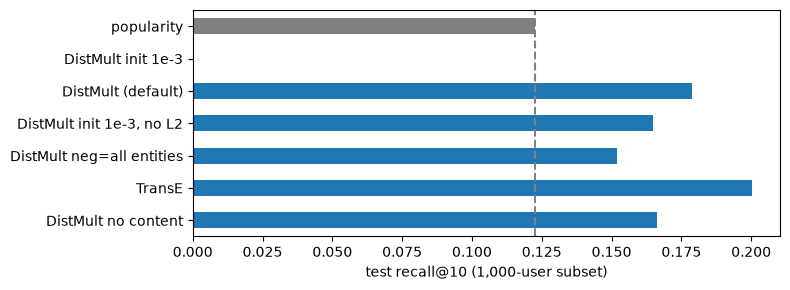

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
table["recall@10"].plot.barh(ax=ax, color=["grey"] + ["C0"] * len(TRIALS))
ax.axvline(POP["recall@10"], ls="--", c="grey")
ax.set_xlabel("test recall@10 (1,000-user subset)")
ax.invert_yaxis()
plt.tight_layout()

## Learning and final decisions

- **Yardstick = popularity** on a per-user holdout, filtered ranking, averaged per user -> 0.123 here, 0.121 full. A model is only interesting above that line.
- **init std 0.1, not 1e-3** -> tiny init × L2 freezes DistMult at zero (either alone doesn't). Loss stuck at its zero-score value (2·ln2) = the diagnostic for a dead model, not a weak one.
- **Range-constrained negatives** -> low loss ≠ good model. 'All-entity' negatives are too easy (loss 0.05) and rank anime worse (0.152 vs 0.179).
- **Keep KG content edges** -> +0.013 recall. First evidence that the KG part is doing work, not just the user–anime matrix.
- **DistMult vs TransE -> keep both in the script, report the full-data numbers.** The winner flips with data size: TransE's rigid geometry = regularizer on 1k users, ceiling on 4.7k. So the model family isn't a fixed winner, it's a bias that fits some data regimes better.
- Subset trials are good for **mechanisms** (init, negatives, content: big clear effects) and weak for **close model picks** (~0.01–0.02 gaps, 8 epochs, one seed) -> those were decided on the full split.
- Not tried on purpose: ComplEx / RotatE (their gains are inversion/composition patterns our graph doesn't have yet), any hyperparameter sweep (goal = explainable choices, not max score).